In [ ]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn. decomposition import PCA
import numpy as np
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
plt.style.use('default')



In [25]:
import torch
import pandas as pd

In [3]:
mix = torch.distributions.Categorical(
    probs=torch.tensor([0.5, 0.2, 0.3])
)

# Componentes (vectorizados)
comp = torch.distributions.Normal(
    loc=torch.tensor([0.0, 2.0, -2.0]),
    scale=torch.tensor([1.0, 0.5, 0.2])
)

# Mezcla Gaussiana
gauss_mix = torch.distributions.MixtureSameFamily(
    mixture_distribution=mix,
    component_distribution=comp
)

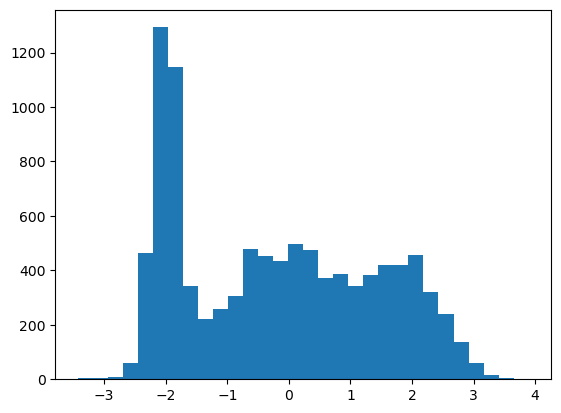

In [4]:
data  = gauss_mix.sample((10000,1))
plt.hist(data.cpu().detach().numpy(), bins=30)
plt.show()

In [5]:
class GaussianMixtureEM:
    def __init__(self, data, n_mix):
        """
        data: tensor (N,) o (N,1)
        n_mix: número de componentes
        """
        self.data = data if data.ndim == 2 else data.unsqueeze(1)
        self.N = self.data.shape[0]
        self.n_mix = n_mix

        # atributos que se llenarán al entrenar
        self.theta = None
        self.log_likelihood_history = []

    def __call__(self, tol=1e-6, max_iter=1000, seed=None):
        if seed is not None:
            torch.manual_seed(seed)

        # ----- inicialización -----
        p = torch.ones(self.n_mix) / self.n_mix
        mu = self.data[torch.randint(0, self.N, (self.n_mix,))].squeeze()
        sigma = torch.ones(self.n_mix)

        self.theta = {"p": [p], "mu": [mu], "sigma": [sigma]}
        self.log_likelihood_history = []

        ll_old = -torch.inf

        for k in range(max_iter):

            # ===== E-step =====
            dist = torch.distributions.Normal(mu, sigma)
            log_probs = dist.log_prob(self.data)           # (N,K)
            log_weighted = log_probs + torch.log(p)        # (N,K)

            log_gamma = log_weighted - torch.logsumexp(log_weighted, dim=1, keepdim=True)
            gamma = torch.exp(log_gamma)

            # ===== M-step =====
            n_k = gamma.sum(dim=0)

            p_new = n_k / self.N
            mu_new = (gamma * self.data).sum(dim=0) / n_k
            var_new = (gamma * (self.data - mu_new)**2).sum(dim=0) / n_k
            sigma_new = torch.sqrt(var_new)

            # evitar problemas numéricos
            sigma_new = torch.clamp(sigma_new, min=1e-6)
            p_new = torch.clamp(p_new, min=1e-8)
            p_new = p_new / p_new.sum()

            # ===== log-likelihood (con parámetros nuevos) =====
            dist_new = torch.distributions.Normal(mu_new, sigma_new)
            log_probs_new = dist_new.log_prob(self.data)
            log_weighted_new = log_probs_new + torch.log(p_new)

            ll = torch.logsumexp(log_weighted_new, dim=1).sum()
            self.log_likelihood_history.append(ll.item())

            print(f"Iter {k}, loglik = {ll.item():.6f}")

            # ===== criterio de paro =====
            if torch.abs(ll - ll_old) < tol:
                print("Convergió")
                break

            ll_old = ll

            # actualizar parámetros
            p, mu, sigma = p_new, mu_new, sigma_new

            # guardar historial
            self.theta["p"].append(p)
            self.theta["mu"].append(mu)
            self.theta["sigma"].append(sigma)

        return self

    def plot_log_likelihood(self):
        plt.figure()
        plt.plot(self.log_likelihood_history)
        plt.xlabel("Iteración")
        plt.ylabel("Log-verosimilitud")
        plt.title("Convergencia EM")
        plt.grid()
        plt.show()

    def plot_density(self, bins=50, show_components=True):
        """
        Grafica el histograma de los datos junto con la densidad estimada.
        """

        # últimos parámetros estimados
        p = self.theta["p"][-1]
        mu = self.theta["mu"][-1]
        sigma = self.theta["sigma"][-1]

        data = self.data.squeeze()

        # grid para evaluar densidad
        x_min, x_max = data.min().item(), data.max().item()
        x = torch.linspace(x_min, x_max, 500)

        # densidad total
        density = torch.zeros_like(x)

        for j in range(self.n_mix):
            dist = torch.distributions.Normal(mu[j], sigma[j])
            density += p[j] * torch.exp(dist.log_prob(x))

        # ===== plot =====
        plt.figure()

        # histograma
        plt.hist(data.numpy(), bins=bins, density=True, alpha=0.5)

        # mezcla total
        plt.plot(x.numpy(), density.detach().numpy(), linewidth=2, label="Mixture")

        # componentes individuales
        if show_components:
            for j in range(self.n_mix):
                dist = torch.distributions.Normal(mu[j], sigma[j])
                comp_density = p[j] * torch.exp(dist.log_prob(x))
                plt.plot(x.numpy(), comp_density.detach().numpy(), linestyle="--")

        plt.title("Ajuste de Mezcla Gaussiana (EM)")
        plt.xlabel("x")
        plt.ylabel("Densidad")
        plt.legend()
        plt.grid()

        plt.show()

In [6]:
model = GaussianMixtureEM(data, n_mix=3)
model(tol=1e-10, seed=42)


Iter 0, loglik = -17603.347656
Iter 1, loglik = -17440.029297
Iter 2, loglik = -17217.220703
Iter 3, loglik = -16843.449219
Iter 4, loglik = -16428.451172
Iter 5, loglik = -16218.958984
Iter 6, loglik = -16161.766602
Iter 7, loglik = -16145.654297
Iter 8, loglik = -16137.985352
Iter 9, loglik = -16132.670898
Iter 10, loglik = -16128.425781
Iter 11, loglik = -16124.822266
Iter 12, loglik = -16121.640625
Iter 13, loglik = -16118.745117
Iter 14, loglik = -16116.035156
Iter 15, loglik = -16113.448242
Iter 16, loglik = -16110.932617
Iter 17, loglik = -16108.457031
Iter 18, loglik = -16105.994141
Iter 19, loglik = -16103.523438
Iter 20, loglik = -16101.031250
Iter 21, loglik = -16098.507812
Iter 22, loglik = -16095.946289
Iter 23, loglik = -16093.338867
Iter 24, loglik = -16090.683594
Iter 25, loglik = -16087.976562
Iter 26, loglik = -16085.216797
Iter 27, loglik = -16082.401367
Iter 28, loglik = -16079.533203
Iter 29, loglik = -16076.607422
Iter 30, loglik = -16073.629883
Iter 31, loglik = 

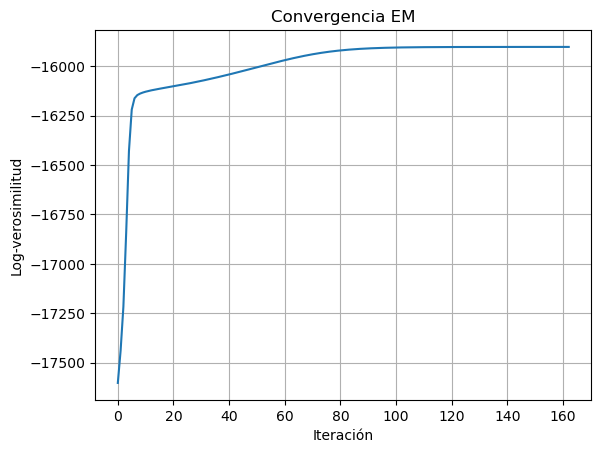

mu: tensor([-2.0037,  1.9828, -0.0372])
sigma: tensor([0.2010, 0.5243, 0.9798])
p: tensor([0.2992, 0.2096, 0.4913])


In [7]:
model.plot_log_likelihood()

# parámetros finales
print("mu:", model.theta["mu"][-1])
print("sigma:", model.theta["sigma"][-1])
print("p:", model.theta["p"][-1])

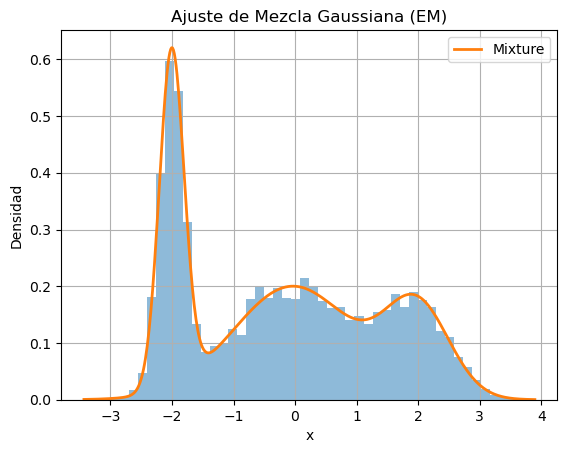

In [8]:
model.plot_density(show_components=False)

In [9]:
data_ins = pd.read_csv("data/claims_q12023.csv",sep=None, engine='python')
data_ins

,cust_age,policy_id,coverage_start_date,cust_region,sum_assured_group,ins_deductible,annual_prem,zip_code,insured_sex,edu_lvl,...,bodily_injuries,witnesses,police_report_avlbl,total_claim_amount,injury_claim,property_claim,vehicle_claim,car_brand,car_model,production_year
0,44,225016,08.09.2007,north,mid,2000,1007.48,342178,F,college,...,0,2,YES,74140,13480,13480,47180,BMW,X5,2022
1,56,316183,02.02.2016,north,mid,500,1080.60,506682,F,phd,...,2,3,NaN,56430,0,6270,50160,Honda,CRV,2021
2,28,174430,04.02.2020,east,mid,2000,1078.03,330854,M,high school,...,0,1,YES,53600,6700,6700,40200,Volkswagen,Jetta,2014
3,53,67527,27.01.2013,north,low,1000,1026.55,502272,F,college,...,0,0,NO,80960,14720,7360,58880,Accura,MDX,2007
4,47,259758,08.04.2015,east,mid,2000,1484.15,515656,F,associate,...,2,3,NaN,64100,12820,6410,44870,Dodge,RAM,2021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,53,477651,03.03.1998,west,low,2000,1394.54,348690,F,associate,...,2,1,NaN,47430,5270,5270,36890,Toyota,Camry,2007
996,32,265179,20.11.2013,east,high,2000,1255.11,516309,F,high school,...,1,3,NO,61270,5570,11140,44560,Subaru,Legacy,2006
997,29,182883,11.09.2013,west,low,1000,1521.28,510447,M,masters,...,1,2,YES,94560,7880,15760,70920,Jeep,Grand Cherokee,2002
998,56,438442,28.10.2009,west,mid,500,1040.67,516735,M,high school,...,0,2,NO,68040,15120,7560,45360,Subaru,Forrestor,2004


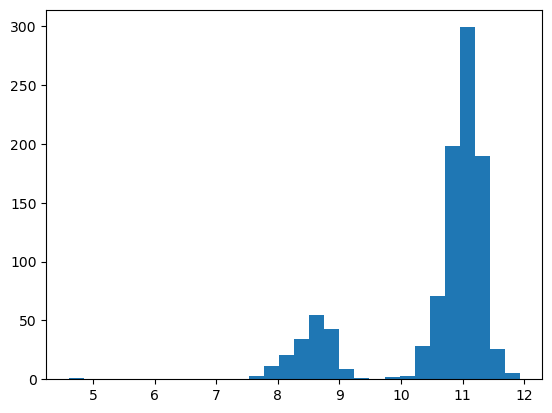

In [10]:
x = torch.tensor(data_ins["total_claim_amount"]).log()
plt.hist(x.cpu(), bins=30)
plt.show()

In [11]:
model_cm = GaussianMixtureEM(x, n_mix=2)
model_cm(tol=1e-10, seed=1997)

Iter 0, loglik = -1377.039551
Iter 1, loglik = -1209.534912
Iter 2, loglik = -858.950562
Iter 3, loglik = -767.977722
Iter 4, loglik = -746.154175
Iter 5, loglik = -736.492920
Iter 6, loglik = -729.177795
Iter 7, loglik = -721.400513
Iter 8, loglik = -711.245911
Iter 9, loglik = -698.174255
Iter 10, loglik = -684.639282
Iter 11, loglik = -675.884521
Iter 12, loglik = -673.523926
Iter 13, loglik = -673.295288
Iter 14, loglik = -673.284424
Iter 15, loglik = -673.284180
Iter 16, loglik = -673.284058
Iter 17, loglik = -673.284058
Convergió


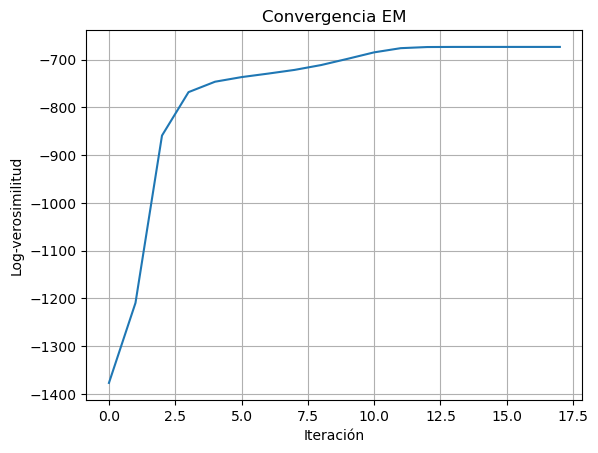

mu: tensor([ 8.5468, 11.0217])
sigma: tensor([0.4681, 0.2681])
p: tensor([0.1804, 0.8196])


In [12]:
model_cm.plot_log_likelihood()
# parámetros finales
print("mu:", model_cm.theta["mu"][-1])
print("sigma:", model_cm.theta["sigma"][-1])
print("p:", model_cm.theta["p"][-1])

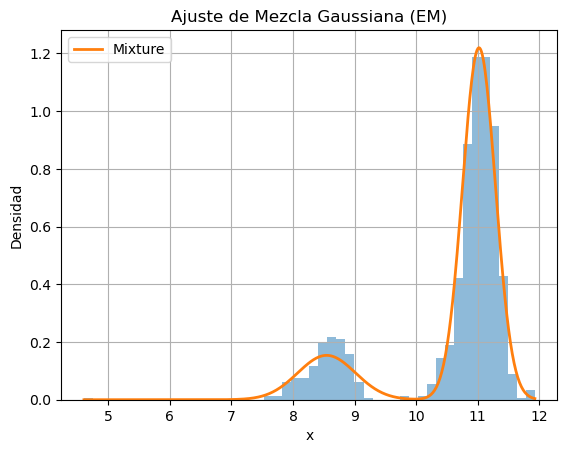

In [13]:
model_cm.plot_density(show_components=False)

In [16]:
class GaussianMixtureEMMultivariate:
    def __init__(self, data, n_mix):
        """
        data: tensor (N,D)
        n_mix: número de clusters
        """
        self.data = data if data.ndim == 2 else data.unsqueeze(1)
        self.N, self.D = self.data.shape
        self.K = n_mix

        self.theta = None
        self.log_likelihood_history = []
        self.gamma = None  # responsabilidades finales

    def __call__(self, tol=1e-6, max_iter=1000, seed=None):

        if seed is not None:
            torch.manual_seed(seed)

        # ===== inicialización =====
        p = torch.ones(self.K) / self.K

        # medias: (K, D)
        mu = self.data[torch.randint(0, self.N, (self.K,))]

        # covarianzas: (K, D, D)
        Sigma = torch.stack([torch.eye(self.D) for _ in range(self.K)])

        self.theta = {"p": [p], "mu": [mu], "Sigma": [Sigma]}
        self.log_likelihood_history = []

        ll_old = -torch.inf

        for it in range(max_iter):

            # ===== E-step =====
            dist = torch.distributions.MultivariateNormal(mu, Sigma)

            # (N, K)
            log_probs = dist.log_prob(self.data.unsqueeze(1))

            log_weighted = log_probs + torch.log(p)
            log_gamma = log_weighted - torch.logsumexp(log_weighted, dim=1, keepdim=True)
            gamma = torch.exp(log_gamma)

            # ===== M-step =====
            n_k = gamma.sum(dim=0)  # (K,)

            p_new = n_k / self.N

            # medias (K, D)
            mu_new = (gamma.unsqueeze(-1) * self.data.unsqueeze(1)).sum(dim=0) / n_k.unsqueeze(-1)

            # ===== covarianzas =====
            diff = self.data.unsqueeze(1) - mu_new.unsqueeze(0)  # (N, K, D)

            # producto externo → (N, K, D, D)
            outer = diff.unsqueeze(-1) * diff.unsqueeze(-2)

            # ponderación
            Sigma_new = (gamma.unsqueeze(-1).unsqueeze(-1) * outer).sum(dim=0) / n_k.view(self.K, 1, 1)

            # ===== estabilidad numérica =====
            eps = 1e-6
            eye = torch.eye(self.D, device=self.data.device).unsqueeze(0)
            Sigma_new = Sigma_new + eps * eye

            p_new = torch.clamp(p_new, min=1e-8)
            p_new = p_new / p_new.sum()

            # ===== log-likelihood =====
            dist_new = torch.distributions.MultivariateNormal(mu_new, Sigma_new)

            log_probs_new = dist_new.log_prob(self.data.unsqueeze(1))
            log_weighted_new = log_probs_new + torch.log(p_new)

            ll = torch.logsumexp(log_weighted_new, dim=1).sum()
            self.log_likelihood_history.append(ll.item())

            print(f"Iter {it}, loglik = {ll.item():.6f}")

            if torch.abs(ll - ll_old) < tol:
                print("Convergió")
                break

            ll_old = ll

            p, mu, Sigma = p_new, mu_new, Sigma_new

            self.theta["p"].append(p)
            self.theta["mu"].append(mu)
            self.theta["Sigma"].append(Sigma)

        self.gamma = gamma
        return self




    # ===== Predicciones =====
    def predict(self):
        return self.gamma.argmax(dim=1)

    def predict_proba(self):
        return self.gamma

    # ===== Visualización =====
    def plot_clusters(self):
        labels = self.predict()
        X = self.data

        if self.D == 1:
            plt.scatter(X[:, 0], torch.zeros_like(X[:, 0]), c=labels)
            plt.xlabel("x")
            plt.title("Clusters en 1D")

        elif self.D == 2:
            plt.scatter(X[:, 0], X[:, 1], c=labels)
            plt.xlabel("x1")
            plt.ylabel("x2")
            plt.title("Clusters en 2D")

        elif self.D == 3:
            fig = plt.figure()
            ax = fig.add_subplot(111, projection='3d')
            ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=labels)
            ax.set_xlabel("x1")
            ax.set_ylabel("x2")
            ax.set_zlabel("x3")
            ax.set_title("Clusters en 3D")

        else:
            print("Visualización solo soporta D=1,2,3")

        plt.show()

Iter 0, loglik = -711.161987
Iter 1, loglik = -711.161438
Iter 2, loglik = -711.161499
Iter 3, loglik = -711.161499
Convergió


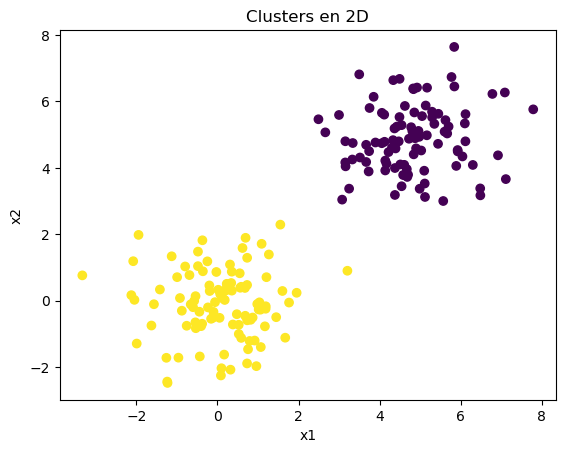

In [17]:
X1 = torch.randn(100, 2) + torch.tensor([0., 0.])
X2 = torch.randn(100, 2) + torch.tensor([5., 5.])
X = torch.cat([X1, X2], dim=0)

model = GaussianMixtureEMMultivariate(X, n_mix=2)
model()

model.plot_clusters()

In [18]:
model.predict_proba()

tensor([[3.1076e-06, 1.0000e+00],
        [6.9936e-11, 1.0000e+00],
        [8.1990e-10, 1.0000e+00],
        [2.9758e-09, 1.0000e+00],
        [3.3238e-09, 1.0000e+00],
        [6.8760e-06, 9.9999e-01],
        [1.5394e-05, 9.9998e-01],
        [4.5803e-11, 1.0000e+00],
        [1.2652e-10, 1.0000e+00],
        [1.6745e-10, 1.0000e+00],
        [1.3174e-13, 1.0000e+00],
        [1.4627e-07, 1.0000e+00],
        [8.4603e-05, 9.9992e-01],
        [1.1246e-10, 1.0000e+00],
        [9.1828e-08, 1.0000e+00],
        [1.8649e-09, 1.0000e+00],
        [1.0577e-08, 1.0000e+00],
        [1.3058e-08, 1.0000e+00],
        [1.5151e-08, 1.0000e+00],
        [2.6724e-11, 1.0000e+00],
        [3.1758e-09, 1.0000e+00],
        [4.6340e-17, 1.0000e+00],
        [7.0702e-09, 1.0000e+00],
        [2.6934e-08, 1.0000e+00],
        [1.4390e-09, 1.0000e+00],
        [1.4322e-09, 1.0000e+00],
        [3.3163e-11, 1.0000e+00],
        [1.9188e-09, 1.0000e+00],
        [2.9920e-09, 1.0000e+00],
        [6.513

In [19]:
model.theta["p"][-1]

tensor([0.5002, 0.4998])

In [20]:
model.theta["mu"][-1]

tensor([[ 4.7929,  4.8507],
        [ 0.0652, -0.0989]])

In [22]:
model.theta["Sigma"][-1]

tensor([[[1.0344, 0.1127],
         [0.1127, 0.9596]],

        [[1.0535, 0.0190],
         [0.0190, 1.0752]]])

In [26]:
fifa_20 = pd.read_csv('data/players_20.csv')
features = list(fifa_20.columns[fifa_20.dtypes=='int64'])[11:]
target = ['overall']

In [29]:
scaler_X = StandardScaler()
scaler_X.fit(np.array(fifa_20[features]))

def pre_data(df, scaler_X):

    X = df[features]
    y = np.array(df[target])

    X = scaler_X.transform(X)

    return X,y

X , y = pre_data(fifa_20, scaler_X)

pca = PCA()
pca.fit(X)
CPX = pca.transform(X)

C:\Users\Academica\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


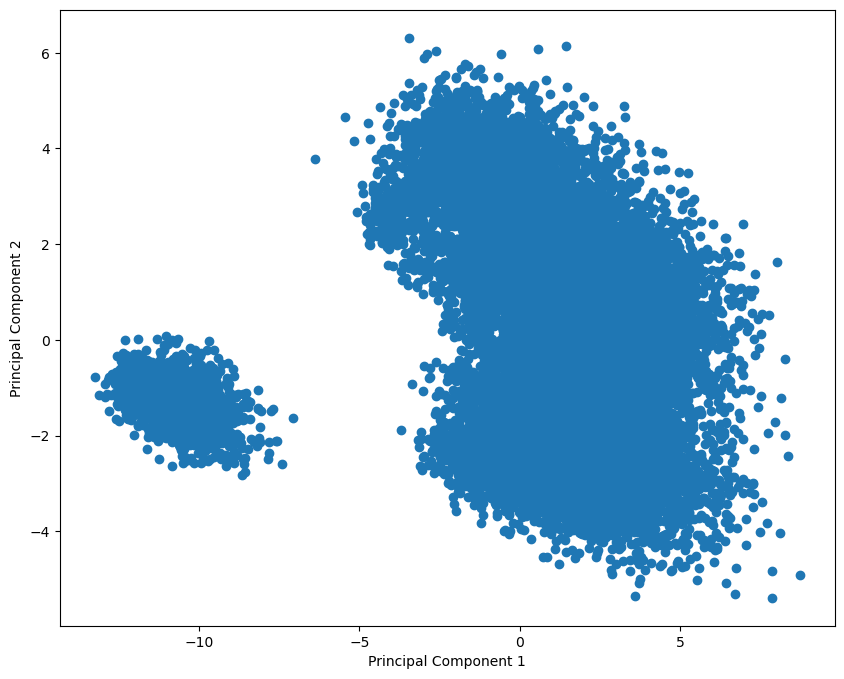

In [30]:
plt.figure(figsize=(10,8))
plt.scatter(CPX[:,0],CPX[:,1])
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.plot()
plt.show()

Iter 0, loglik = -84657.296875
Iter 1, loglik = -84513.921875
Iter 2, loglik = -84312.398438
Iter 3, loglik = -83738.062500
Iter 4, loglik = -82042.343750
Iter 5, loglik = -81629.820312
Iter 6, loglik = -81629.804688
Iter 7, loglik = -81629.812500
Iter 8, loglik = -81629.812500
Convergió


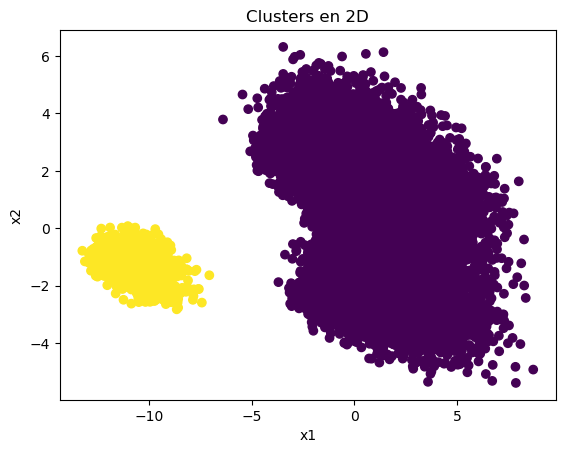

In [37]:
pca_data_fifa = torch.Tensor(CPX[:,:2])
gmm_fifa = GaussianMixtureEMMultivariate(pca_data_fifa, n_mix=2)
gmm_fifa()
gmm_fifa.plot_clusters()

In [39]:
gmm_fifa.theta["p"][-1]

tensor([0.8886, 0.1114])

In [40]:
gmm_fifa.theta["mu"][-1]

tensor([[  1.3379,   0.1597],
        [-10.6732,  -1.2739]])

In [41]:
gmm_fifa.theta["Sigma"][-1]

tensor([[[ 4.8344, -1.8923],
         [-1.8923,  5.3551]],

        [[ 0.9676, -0.2045],
         [-0.2045,  0.2123]]])

Iter 0, loglik = -84400.593750
Iter 1, loglik = -83859.148438
Iter 2, loglik = -83563.109375
Iter 3, loglik = -83315.835938
Iter 4, loglik = -83069.000000
Iter 5, loglik = -82811.015625
Iter 6, loglik = -82544.617188
Iter 7, loglik = -82249.234375
Iter 8, loglik = -81805.867188
Iter 9, loglik = -80822.984375
Iter 10, loglik = -79156.468750
Iter 11, loglik = -79123.992188
Iter 12, loglik = -79107.007812
Iter 13, loglik = -79092.234375
Iter 14, loglik = -79079.140625
Iter 15, loglik = -79067.492188
Iter 16, loglik = -79057.148438
Iter 17, loglik = -79047.960938
Iter 18, loglik = -79039.828125
Iter 19, loglik = -79032.648438
Iter 20, loglik = -79026.335938
Iter 21, loglik = -79020.781250
Iter 22, loglik = -79015.906250
Iter 23, loglik = -79011.640625
Iter 24, loglik = -79007.875000
Iter 25, loglik = -79004.562500
Iter 26, loglik = -79001.625000
Iter 27, loglik = -78999.023438
Iter 28, loglik = -78996.703125
Iter 29, loglik = -78994.609375
Iter 30, loglik = -78992.726562
Iter 31, loglik = 

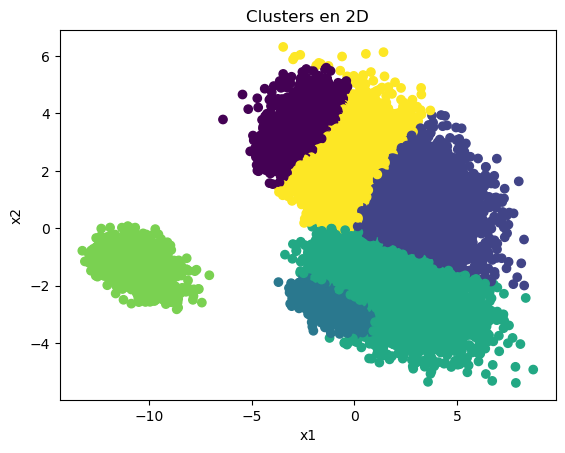

In [51]:
pca_data_fifa = torch.Tensor(CPX[:,:2])
gmm_fifa = GaussianMixtureEMMultivariate(pca_data_fifa, n_mix=6)
gmm_fifa(seed=1)
gmm_fifa.plot_clusters()

In [54]:
fifa_20['cluster'] = gmm_fifa.predict()
fifa_20[['short_name','cluster','player_positions', 'overall']].query('cluster==0')

,short_name,cluster,player_positions,overall
1033,J. Bednarek,0,CB,77
1169,S. De Maio,0,CB,77
1253,J. Monsario,0,CB,77
1313,Unai Núñez,0,CB,76
1326,Y. Osorio,0,CB,76
...,...,...,...,...
18260,A. De Angelis,0,"CDM, CM",48
18262,S. Callan,0,"CB, RB",48
18263,F. Nevarez,0,RB,48
18273,Shao Shuai,0,CB,48


In [55]:
fifa_20[['short_name','cluster','player_positions', 'overall']].query('cluster==1')

,short_name,cluster,player_positions,overall
5,K. De Bruyne,1,"CAM, CM",91
7,V. van Dijk,1,CB,90
8,L. Modrić,1,CM,90
15,N. Kanté,1,"CDM, CM",89
18,Sergio Ramos,1,CB,89
...,...,...,...,...
17030,R. Tsonev,1,"CM, CAM, RM",56
17068,J. Russell,1,"CM, CDM",56
17087,I. Angking,1,CDM,55
17464,L. Doyle,1,CM,54


In [56]:
fifa_20[['short_name','cluster','player_positions']].query('cluster==2')

,short_name,cluster,player_positions
5815,A. Bareiro,2,ST
6077,M. Suzuki,2,"ST, CF, LW"
6754,Leonardo Rocha,2,ST
7000,Gonçalo Gregório,2,ST
7117,C. Monschein,2,"ST, LM"
...,...,...,...
18248,T. Klysner,2,"LW, LM"
18250,R. Roache,2,ST
18254,E. Jääskeläinen,2,ST
18257,Song Min Kyu,2,LW


In [57]:
fifa_20[['short_name','cluster','player_positions']].query('cluster==3')

,short_name,cluster,player_positions
0,L. Messi,3,"RW, CF, ST"
1,Cristiano Ronaldo,3,"ST, LW"
2,Neymar Jr,3,"LW, CAM"
4,E. Hazard,3,"LW, CF"
9,M. Salah,3,"RW, ST"
...,...,...,...
18249,Shan Huanhuan,3,ST
18255,C. Heath,3,CM
18258,L. Collins,3,CM
18266,Wang Peng,3,CAM
